# Simple Sine Wave

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def create_infinite_fast_stream_10_cycles(wave_function, title="Infinite Live Stream", total_frames=200, interval=15, color="crimson", y_min=-1.5, y_max=1.5):
    """
    High-performance infinite live drawing engine showing exactly 10 complete cycles
    with thresholds at 0.75, -0.75 and a baseline axis at 0.0. No legend included.
    """
    # 10 full cycles equals 10 * 2 * pi
    max_x = 10 * 2 * np.pi

    # 1. Prepare the static figure framework ONCE
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_xlim(0, max_x)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.3)

    # 2. ADD STATIC THRESHOLDS (Without label arguments)
    ax.axhline(0.75, color="gray", linestyle="--", alpha=0.7)
    ax.axhline(0.0, color="black", linestyle="-", alpha=0.5)
    ax.axhline(-0.75, color="gray", linestyle="--", alpha=0.7)

    # REMOVED: ax.legend(loc="upper right") has been deleted to clean up the plot area

    # 3. Initialize empty permanent graphic objects
    line, = ax.plot([], [], color=color, linewidth=3)
    brush_tip, = ax.plot([], [], color="black", marker="o", markersize=8)

    # Stretch the calculations across the entire 10-cycle X-axis width
    x_space = np.linspace(0, max_x, total_frames)
    sleep_time = interval / 1000.0

    try:
        while True:
            x_data, y_data = [], []

            for i in range(total_frames):
                current_x = x_space[i]
                current_y = wave_function(current_x)

                x_data.append(current_x)
                y_data.append(current_y)

                # 4. FAST REFRESH: Push data directly into existing graphic layers
                line.set_data(x_data, y_data)
                brush_tip.set_data([current_x], [current_y])

                # 5. Instant screen update
                clear_output(wait=True)
                display(fig)

                time.sleep(sleep_time)

            # Pause before restarting the loop from the left edge
            time.sleep(0.3)

    except KeyboardInterrupt:
        print("\n[INFO] Infinite live streaming animation stopped by user.")

    finally:
        plt.close(fig)


In [13]:
def simple_sine(x):
    return np.sin(x)

# Launch using the correct 10-cycle function reference
create_infinite_fast_stream_10_cycles(
    simple_sine,
    title="10 Full Sine Wave Cycles with Baseline",
    total_frames=250, # More frames make the 10 waves look sharper
    interval=10,       # Fast refresh rate
    color="teal"
)



[INFO] Infinite live streaming animation stopped by user.


# Basic Mean Reversion

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def create_mean_reversion_persistent_stream(wave_function, title="Mean Reversion Bot with Trade History", total_frames=200, interval=15, color="teal", y_min=-1.5, y_max=1.5):
    """
    High-performance live drawing engine where past fill_between trade zones
    remain persistently on the screen as history. Fixed property setter bug.
    """
    max_x = 10 * 2 * np.pi

    fig, ax = plt.subplots(figsize=(12, 5))

    x_space = np.linspace(0, max_x, total_frames)
    sleep_time = interval / 1000.0

    try:
        while True:
            # 1. SAFE CLEAR: Reset the entire axes object at every master loop restart
            ax.clear()
            ax.set_xlim(0, max_x)
            ax.set_ylim(y_min, y_max)
            ax.set_title(title, fontsize=12)
            ax.grid(True, linestyle="--", alpha=0.3)

            # Re-draw the static baseline thresholds on the clean canvas
            ax.axhline(0.75, color="gray", linestyle="--", alpha=0.7)
            ax.axhline(0.0, color="black", linestyle="-", alpha=0.5)
            ax.axhline(-0.75, color="gray", linestyle="--", alpha=0.7)

            # Re-initialize the line layer components inside the fresh axes context
            line, = ax.plot([], [], color=color, linewidth=3)
            brush_tip, = ax.plot([], [], color="black", marker="o", markersize=8)

            x_data, y_data = [], []
            active_fill = None

            in_short_trade = False
            in_long_trade = False
            trade_x, trade_y = [], []

            for i in range(total_frames):
                current_x = x_space[i]
                current_y = wave_function(current_x)

                x_data.append(current_x)
                y_data.append(current_y)

                # --- MEAN REVERSION BOT LOGIC ---

                # Trigger SHORT trade (Sell)
                if not in_short_trade and not in_long_trade and current_y >= 0.75:
                    in_short_trade = True
                    trade_x, trade_y = [current_x], [current_y]

                # Trigger LONG trade (Buy)
                elif not in_short_trade and not in_long_trade and current_y <= -0.75:
                    in_long_trade = True
                    trade_x, trade_y = [current_x], [current_y]

                # Inside active trade
                elif in_short_trade or in_long_trade:
                    trade_x.append(current_x)
                    trade_y.append(current_y)

                    # Exit trade condition (price hits or crosses baseline)
                    if (in_short_trade and current_y <= 0.0) or (in_long_trade and current_y >= 0.0):
                        fill_color = "coral" if in_short_trade else "lightgreen"
                        # Bake this block into the background permanent layers
                        ax.fill_between(trade_x, trade_y, 0, color=fill_color, alpha=0.5)

                        in_short_trade = False
                        in_long_trade = False
                        trade_x, trade_y = [], []
                        active_fill = None

                # --- RENDERING CODES ---

                # Erase only the temporary active fill of the current frame
                if active_fill is not None:
                    active_fill.remove()
                    active_fill = None

                # Generate a temporary growing fill layer if trade is actively running
                if len(trade_x) > 0:
                    fill_color = "coral" if in_short_trade else "lightgreen"
                    active_fill = ax.fill_between(trade_x, trade_y, 0, color=fill_color, alpha=0.5)

                # Refresh dynamic line data coordinates
                line.set_data(x_data, y_data)
                brush_tip.set_data([current_x], [current_y])

                clear_output(wait=True)
                display(fig)

                time.sleep(sleep_time)

            # time.sleep(0.5)

    except KeyboardInterrupt:
        print("\n[INFO] Mean reversion simulation stopped by user.")

    finally:
        plt.close(fig)


In [34]:
def simple_sine(x):
    return np.sin(x)

create_mean_reversion_persistent_stream(
    simple_sine,
    title="Mean Reversion Trading",
    total_frames=250,
    interval=12,
    color="darkslateblue"
)



[INFO] Mean reversion simulation stopped by user.


# Regime Breakout (linear)

In [18]:
def market_breakout_at_peak_wave(x):
    """
    Simulates an asset price that oscillates normally, hits a peak of 1.0
    exactly at the halfway point, and then breaks out linearly towards 5.0.
    """
    halfway_point = 5 * 2 * np.pi
    max_x = 10 * 2 * np.pi

    if x < halfway_point:
        # First half: adding np.pi/2 forces the wave to be at exactly 1.0
        # when x reaches the halfway_point.
        return np.sin(x + np.pi / 2)
    else:
        # Second half: straight line starting exactly from 1.0 at the halfway point
        # and climbing continuously up to 5.0 at the end of the plot (max_x).
        slope = (5.0 - 1.0) / (max_x - halfway_point)
        return 1.0 + slope * (x - halfway_point)


In [19]:
# Launch the simulation with adjusted Y limits to accommodate the climb to 5.0
create_mean_reversion_persistent_stream(
    market_breakout_at_peak_wave,
    title="Mean Reversion Bot Failure: Bullish Breakout Scenario",
    total_frames=250,
    interval=1, # 12
    color="darkslateblue",
    y_min=-1.5,
    y_max=5.5 # Expanded Y-axis to see the asset fly up to 5.0
)



[INFO] Mean reversion simulation stopped by user.


# Regime breakout (with oscillation)

In [20]:
def market_breakout_with_oscillations_wave(x):
    """
    Simulates a price hitting a peak of 1.0 at the halfway point,
    then breaking out towards 5.0 with constant, small-amplitude oscillations.
    """
    halfway_point = 5 * 2 * np.pi
    max_x = 10 * 2 * np.pi

    if x < halfway_point:
        # First half: normal sine wave peaking at exactly 1.0 at the halfway mark
        return np.sin(x + np.pi / 2)
    else:
        # Second half: Linear upward trend (the baseline climbs from 1.0 to 5.0)
        slope = (5.0 - 1.0) / (max_x - halfway_point)
        linear_trend = 1.0 + slope * (x - halfway_point)

        # FIX 1: Constant small amplitude (no fade-in)
        constant_amplitude = 0.2

        # FIX 2: Shifted frequency phase starting exactly at 0.0 at the halfway mark.
        # Multiplying by 2.0 keeps the wave frequency snappy.
        market_noise = constant_amplitude * np.sin(2.0 * (x - halfway_point))

        return linear_trend + market_noise


In [21]:
create_mean_reversion_persistent_stream(
    market_breakout_with_oscillations_wave,
    title="Mean Reversion Failure: Breakout with Market Oscillations",
    total_frames=250,
    interval=12,
    color="darkslateblue",
    y_min=-1.5,
    y_max=5.5
)



[INFO] Mean reversion simulation stopped by user.


# Stop-loss trigger

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def create_mean_reversion_crash_marker_stream(wave_function, title="Mean Reversion Bot - Emergency Shutdown", total_frames=200, interval=15, color="teal", y_min=-1.5, y_max=1.5):
    """
    High-performance live drawing engine with persistent trade history.
    Shifted text significantly left and added an opaque background box to prevent occlusion.
    """
    max_x = 10 * 2 * np.pi

    fig, ax = plt.subplots(figsize=(12, 5))
    x_space = np.linspace(0, max_x, total_frames)
    sleep_time = interval / 1000.0

    try:
        while True:
            ax.clear()
            ax.set_xlim(0, max_x)
            ax.set_ylim(y_min, y_max)
            ax.set_title(title, fontsize=12)
            ax.grid(True, linestyle="--", alpha=0.3)

            # Static thresholds
            ax.axhline(0.75, color="gray", linestyle="--", alpha=0.7)
            ax.axhline(0.0, color="black", linestyle="-", alpha=0.5)
            ax.axhline(-0.75, color="gray", linestyle="--", alpha=0.7)
            ax.axhline(2.5, color="crimson", linestyle=":", alpha=0.6)

            # Initialize empty permanent graphic lines
            line, = ax.plot([], [], color=color, linewidth=3)
            brush_tip, = ax.plot([], [], color="black", marker="o", markersize=8)

            # Placeholders for the crash marker and text
            crash_cross, = ax.plot([], [], color="crimson", marker="X", markersize=12)

            # FIX 1: Added a white opaque background box (bbox) to cover the line if it passes over it
            crash_label = ax.text(
                0, 0, "", color="crimson", fontweight="bold", fontsize=10, ha="right",
                bbox=dict(facecolor='white', edgecolor='crimson', boxstyle='round,pad=0.3', alpha=1.0)
            )

            x_data, y_data = [], []
            active_fill = None

            in_short_trade = False
            in_long_trade = False
            trade_x, trade_y = [], []

            bot_is_disabled = False
            crash_coordinates = None

            for i in range(total_frames):
                current_x = x_space[i]
                current_y = wave_function(current_x)

                x_data.append(current_x)
                y_data.append(current_y)

                # --- MEAN REVERSION BOT LOGIC ---
                if not bot_is_disabled and not in_short_trade and not in_long_trade:
                    if current_y >= 0.75:
                        in_short_trade = True
                        trade_x, trade_y = [current_x], [current_y]
                    elif current_y <= -0.75:
                        in_long_trade = True
                        trade_x, trade_y = [current_x], [current_y]

                elif in_short_trade or in_long_trade:
                    trade_x.append(current_x)
                    trade_y.append(current_y)

                    # TARGET HIT (Normal exit)
                    if (in_short_trade and current_y <= 0.0) or (in_long_trade and current_y >= 0.0):
                        fill_color = "coral" if in_short_trade else "lightgreen"
                        ax.fill_between(trade_x, trade_y, 0, color=fill_color, alpha=0.5)
                        in_short_trade, in_long_trade = False, False
                        trade_x, trade_y = [], []
                        active_fill = None

                    # STOP-LOSS HIT (Emergency shutdown)
                    elif (in_short_trade and current_y >= 2.5) or (in_long_trade and current_y <= -2.5):
                        fill_color = "coral" if in_short_trade else "lightgreen"
                        ax.fill_between(trade_x, trade_y, 0, color=fill_color, alpha=0.5)

                        crash_coordinates = (current_x, current_y)

                        in_short_trade, in_long_trade = False, False
                        trade_x, trade_y = [], []
                        active_fill = None
                        bot_is_disabled = True

                # --- RENDERING CODES ---
                if active_fill is not None:
                    active_fill.remove()
                    active_fill = None

                if len(trade_x) > 0:
                    fill_color = "coral" if in_short_trade else "lightgreen"
                    active_fill = ax.fill_between(trade_x, trade_y, 0, color=fill_color, alpha=0.5)

                # Update data properties without duplicate stacking
                if crash_coordinates is not None:
                    cx, cy = crash_coordinates
                    crash_cross.set_data([cx], [cy])

                    # FIX 2: Increased the horizontal offset to -4.0 to push it completely out of the curve's way
                    crash_label.set_position((cx - 4.0, cy))
                    crash_label.set_text("CRASH / STOP-LOSS ──►")

                line.set_data(x_data, y_data)
                brush_tip.set_data([current_x], [current_y])

                clear_output(wait=True)
                display(fig)

                time.sleep(sleep_time)

            time.sleep(0.5)

    except KeyboardInterrupt:
        print("\n[INFO] Mean reversion simulation stopped by user.")

    finally:
        plt.close(fig)


In [36]:
create_mean_reversion_crash_marker_stream(
    market_breakout_with_oscillations_wave,
    title="Mean Reversion Risk Management: Emergency Stop-Loss Execution",
    total_frames=250,
    interval=12,
    color="darkslateblue",
    y_min=-1.5,
    y_max=5.5
)



[INFO] Mean reversion simulation stopped by user.


# Three Regimes

In [24]:
def market_three_regimes_wave(x):
    """
    Simulates an asset price experiencing 3 distinct market regimes with a perfect,
    seamless phase connection at the second transition point.
    """
    # Define our precise transition markers (total width is 10 * 2 * pi)
    start_bull_run = 4 * 2 * np.pi
    end_bull_run = 7 * 2 * np.pi
    max_x = 10 * 2 * np.pi

    noise_amplitude = 0.2

    # --- REGIME 1: Initial Stable Market ---
    if x < start_bull_run:
        # Standard sine wave peaking perfectly at 1.0 right before the transition
        return np.sin(x + np.pi / 2)

    # --- REGIME 2: The Bull Run Phase ---
    elif start_bull_run <= x < end_bull_run:
        # Linear upward baseline trend climbing from 1.0 to 4.0
        slope = (4.0 - 1.0) / (end_bull_run - start_bull_run)
        linear_trend = 1.0 + slope * (x - start_bull_run)

        # Smooth constant oscillations around the trend (ends exactly at 0.0)
        market_noise = noise_amplitude * np.sin(2.0 * (x - start_bull_run))
        return linear_trend + market_noise

    # --- REGIME 3: New High-Altitude Stable Market ---
    else:
        # Fixed baseline at the new height of 4.0
        new_baseline = 4.0

        # FIX: Remove 'np.pi / 2' to start the sine wave at exactly 0.0.
        # This eliminates the vertical jump and ensures a flawless, clean transition.
        stable_wave = np.sin(x - end_bull_run)

        return new_baseline + stable_wave


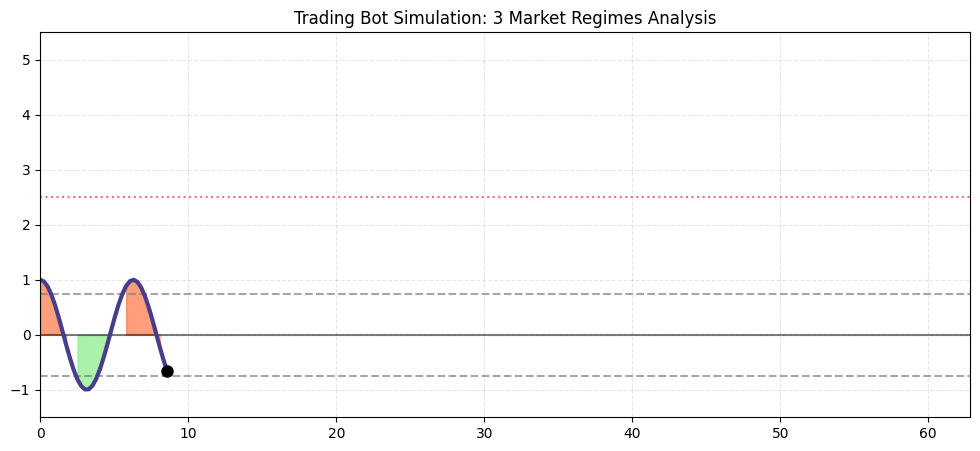


[INFO] Mean reversion simulation stopped by user.


In [25]:
create_mean_reversion_crash_marker_stream(
    market_three_regimes_wave,
    title="Trading Bot Simulation: 3 Market Regimes Analysis",
    total_frames=250,
    interval=12,
    color="darkslateblue",
    y_min=-1.5,
    y_max=5.5
)


# Adaptative Mean Reversion

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def create_multi_regime_static_bot_stream(wave_function, title="Multi-Regime Fixed Threshold Bot", total_frames=250, interval=12, color="teal", y_min=-1.5, y_max=5.5):
    """
    High-performance live drawing engine where the bot shifts its static thresholds
    instantly when entering the 3rd regime, while keeping the historical CRASH marker visible.
    """
    # Define transition points matching our 3 market regimes
    start_bull_run = 4 * 2 * np.pi
    end_bull_run = 7 * 2 * np.pi
    max_x = 10 * 2 * np.pi

    fig, ax = plt.subplots(figsize=(12, 5))
    x_space = np.linspace(0, max_x, total_frames)
    sleep_time = interval / 1000.0

    try:
        while True:
            ax.clear()
            ax.set_xlim(0, max_x)
            ax.set_ylim(y_min, y_max)
            ax.set_title(title, fontsize=12)
            ax.grid(True, linestyle="--", alpha=0.3)

            # Draw the universal emergency Stop-Loss line at 2.5
            ax.axhline(2.5, color="crimson", linestyle=":", alpha=0.6)

            # Initialize empty permanent graphic layers
            line, = ax.plot([], [], color=color, linewidth=3)
            brush_tip, = ax.plot([], [], color="black", marker="o", markersize=8)

            # Placeholders for the permanent historical crash marker
            crash_cross, = ax.plot([], [], color="crimson", marker="X", markersize=12)
            crash_label = ax.text(0, 0, "", color="crimson", fontweight="bold", fontsize=10, ha="right",
                                  bbox=dict(facecolor='white', edgecolor='crimson', boxstyle='round,pad=0.3', alpha=1.0))

            # Placeholders for our static lines (we create them empty, they will switch instantly)
            baseline_line = ax.axhline(0, color="black", linestyle="-", alpha=0)
            upper_line = ax.axhline(0, color="gray", linestyle="--", alpha=0)
            lower_line = ax.axhline(0, color="gray", linestyle="--", alpha=0)

            x_data, y_data = [], []
            active_fill = None

            in_short_trade, in_long_trade = False, False
            trade_x, trade_y = [], []

            bot_is_disabled = False
            crash_coordinates = None

            for i in range(total_frames):
                current_x = x_space[i]
                current_y = wave_function(current_x)

                x_data.append(current_x)
                y_data.append(current_y)

                # --- 1. CONFIGURING STATIC THRESHOLDS BASED ON TIME REGIME ---
                if current_x < end_bull_run:
                    # Regime 1 & 2 layout context parameters
                    current_baseline = 0.0
                    current_upper = 0.75
                    current_lower = -0.75
                else:
                    # Regime 3 layout context parameters: Instant shift to new altitude!
                    current_baseline = 4.0
                    current_upper = 4.75
                    current_lower = 3.25

                # --- 2. MEAN REVERSION BOT LOGIC ---

                # RE-ACTIVATION TRIGGER: If we enter Regime 3, turn the bot engine back on
                if bot_is_disabled and current_x >= end_bull_run:
                    bot_is_disabled = False

                # Entry Rules (Only allowed if bot is active)
                if not bot_is_disabled and not in_short_trade and not in_long_trade:
                    if current_y >= current_upper:
                        in_short_trade = True
                        trade_x, trade_y = [current_x], [current_y]
                    elif current_y <= current_lower:
                        in_long_trade = True
                        trade_x, trade_y = [current_x], [current_y]

                # Inside active trade
                elif in_short_trade or in_long_trade:
                    trade_x.append(current_x)
                    trade_y.append(current_y)

                    # TARGET HIT: Price returned to the active static baseline
                    if (in_short_trade and current_y <= current_baseline) or (in_long_trade and current_y >= current_baseline):
                        fill_color = "coral" if in_short_trade else "lightgreen"
                        ax.fill_between(trade_x, trade_y, current_baseline, color=fill_color, alpha=0.5)
                        in_short_trade, in_long_trade = False, False
                        trade_x, trade_y = [], []
                        active_fill = None

                    # EMERGENCY STOP-LOSS HIT (Only possible during the bull run deviation)
                    elif current_x < end_bull_run and ((in_short_trade and current_y >= 2.5) or (in_long_trade and current_y <= -2.5)):
                        fill_color = "coral" if in_short_trade else "lightgreen"
                        ax.fill_between(trade_x, trade_y, current_baseline, color=fill_color, alpha=0.5)

                        # Lock the crash location coordinates
                        crash_coordinates = (current_x, current_y)

                        in_short_trade, in_long_trade = False, False
                        trade_x, trade_y = [], []
                        active_fill = None

                        # Turn off the bot until the end of the bull run
                        bot_is_disabled = True

                # --- 3. RENDERING CODES ---
                if active_fill is not None:
                    active_fill.remove()
                    active_fill = None

                if len(trade_x) > 0:
                    fill_color = "coral" if in_short_trade else "lightgreen"
                    active_fill = ax.fill_between(trade_x, trade_y, current_baseline, color=fill_color, alpha=0.5)

                # Persistently update and keep the historical crash marker visible
                if crash_coordinates is not None:
                    cx, cy = crash_coordinates
                    crash_cross.set_data([cx], [cy])
                    crash_label.set_position((cx - 4.0, cy))
                    crash_label.set_text("CRASH / STOP-LOSS ──►")

                # Dynamically reposition the rigid threshold guidelines on the active screen canvas
                baseline_line.set_ydata([current_baseline, current_baseline])
                baseline_line.set_alpha(0.6)

                upper_line.set_ydata([current_upper, current_upper])
                upper_line.set_alpha(0.5)

                lower_line.set_ydata([current_lower, current_lower])
                lower_line.set_alpha(0.5)

                # Refresh vector geometries
                line.set_data(x_data, y_data)
                brush_tip.set_data([current_x], [current_y])

                clear_output(wait=True)
                display(fig)

                time.sleep(sleep_time)

            time.sleep(0.5)

    except KeyboardInterrupt:
        print("\n[INFO] Multi-regime simulation stopped by user.")
    finally:
        plt.close(fig)


In [41]:
create_multi_regime_static_bot_stream(
    market_three_regimes_wave,
    title="Fixed Thresholds Bot: Post-Crash High-Altitude Relocation",
    total_frames=250,
    interval=12,
    color="darkslateblue"
)



[INFO] Multi-regime simulation stopped by user.


# Realistic regime change

In [42]:
import numpy as np

def create_variable_regime_market(total_frames=300):
    """
    Generates an asset price curve alternating between stable phases (80% weight)
    and trend phases (20% weight) with highly variable durations.
    Increased oscillation frequency inside the stable regimes while keeping original durations.
    """
    regime_blueprint = [
        ('stable', 0.25,  0.0),  # Long initial consolidation (25% of time)
        ('trend',  0.05,  2.5),  # Fast, explosive breakout upward (5% of time)
        ('stable', 0.15,  0.0),  # Medium stability at high altitude (15% of time)
        ('trend',  0.08, -3.0),  # Sharp crash downward (8% of time)
        ('stable', 0.20,  0.0),  # Long accumulation phase at the bottom (20% of time)
        ('trend',  0.07,  3.5),  # Strong recovery rally (7% of time)
        ('stable', 0.20,  0.0)   # Final distribution phase on top (20% of time)
    ]

    x_space = np.linspace(0, 10 * 2 * np.pi, total_frames)
    y_space = np.zeros(total_frames)

    current_baseline = 0.0
    start_idx = 0

    # FIX 1: Increased stable frequency to 0.4 relative to steps
    # to squeeze more complete wave oscillations inside the same time window
    stable_frequency_factor = 0.4
    trend_frequency_factor = 0.8

    for idx, (regime_type, time_weight, movement) in enumerate(regime_blueprint):
        if idx == len(regime_blueprint) - 1:
            end_idx = total_frames
        else:
            end_idx = start_idx + int(time_weight * total_frames)

        regime_size = end_idx - start_idx

        if regime_size <= 0:
            continue

        time_steps = np.arange(regime_size)

        if regime_type == 'stable':
            # --- HIGH DENSITY STABLE REGIME ---
            # Using time_steps ensures the sine starts smoothly at 0.0 relative to baseline.
            # The frequency factor creates multiple compressed full wave cycles.
            y_space[start_idx:end_idx] = current_baseline + 0.6 * np.sin(stable_frequency_factor * time_steps)

        elif regime_type == 'trend':
            # --- VARIABLE STRONG TREND REGIME ---
            slope = movement / regime_size
            linear_climb = current_baseline + slope * time_steps

            # Subtle vibration noise during the climb
            micro_noise = 0.15 * np.sin(trend_frequency_factor * time_steps)

            y_space[start_idx:end_idx] = linear_climb + micro_noise
            current_baseline += movement

        start_idx = end_idx

    return x_space, y_space


In [43]:
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def stream_multi_regime_market(x_space, y_space, title="Regime-Switching Market Simulation", interval=20, color="darkslateblue"):
    """
    High-performance live drawing engine customized for the multi-regime wave vector.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]

    fig, ax = plt.subplots(figsize=(12, 5))
    sleep_time = interval / 1000.0

    try:
        while True:
            ax.clear()
            ax.set_xlim(0, max_x)
            # Adapt the Y limits automatically to fit the new altitudes cleanly
            ax.set_ylim(min(y_space) - 1.0, max_x_y := max(y_space) + 1.0)
            ax.set_title(title, fontsize=12)
            ax.grid(True, linestyle="--", alpha=0.3)

            line, = ax.plot([], [], color=color, linewidth=3)
            brush_tip, = ax.plot([], [], color="black", marker="o", markersize=8)

            x_data, y_data = [], []

            for i in range(total_frames):
                current_x = x_space[i]
                current_y = y_space[i]

                x_data.append(current_x)
                y_data.append(current_y)

                # Fast data layer updates
                line.set_data(x_data, y_data)
                brush_tip.set_data([current_x], [current_y])

                clear_output(wait=True)
                display(fig)

                time.sleep(sleep_time)

            # Pause before restarting the endless loop from the left
            time.sleep(0.8)

    except KeyboardInterrupt:
        print("\n[INFO] Multi-regime market simulation stopped by user.")
    finally:
        plt.close(fig)


In [44]:
# 1. Compute the variable-duration regime curves (300 frames)
x_var_market, y_var_market = create_variable_regime_market(total_frames=300)

# 2. Launch the endless live stream simulation in your VS Code Notebook
stream_multi_regime_market(x_var_market, y_var_market, title="Asymmetrical Market Cycles (Variable Durations)", interval=15)



[INFO] Multi-regime market simulation stopped by user.


# Realistic noisy market

In [45]:
import numpy as np

def create_true_random_regime_market(total_frames=300):
    """
    Generates a realistic price curve with variable regime durations.
    Uses a highly persistent AR(1) process with optimized parameters
    to create clean, wide, and high-amplitude mean-reverting waves.
    Fixed the scalar indexing bug.
    """
    np.random.seed(42)

    regime_blueprint = [
        ('stable', 0.25,  0.0),  # Long initial consolidation
        ('trend',  0.05,  2.5),  # Fast, explosive breakout upward
        ('stable', 0.15,  0.0),  # Medium stability at high altitude
        ('trend',  0.08, -3.0),  # Sharp crash downward
        ('stable', 0.20,  0.0),  # Long accumulation phase at the bottom
        ('trend',  0.07,  3.5),  # Strong recovery rally
        ('stable', 0.20,  0.0)   # Final distribution phase on top
    ]

    x_space = np.linspace(0, 10 * 2 * np.pi, total_frames)
    y_space = np.zeros(total_frames)

    current_baseline = 0.0
    start_idx = 0

    for idx, (regime_type, time_weight, movement) in enumerate(regime_blueprint):
        if idx == len(regime_blueprint) - 1:
            end_idx = total_frames
        else:
            end_idx = start_idx + int(time_weight * total_frames)

        regime_size = end_idx - start_idx

        if regime_size <= 0:
            continue

        time_steps = np.arange(regime_size)

        if regime_type == 'stable':
            # --- PERSISTENT & HIGH AMPLITUDE AR(1) PROCESS ---
            local_y = np.zeros(regime_size)

            # FIX: Properly set the first element of the array instead of overwriting the array itself
            if start_idx != 0:
                local_y[0] = y_space[start_idx - 1] - current_baseline
            else:
                local_y[0] = 0.0

            phi = 0.96
            shock_volatility = 0.15

            for t in range(1, regime_size):
                # Price wanders far but remains mathematically anchored to the baseline
                local_y[t] = phi * local_y[t-1] + np.random.normal(0, shock_volatility)

            y_space[start_idx:end_idx] = current_baseline + local_y

        elif regime_type == 'trend':
            # --- LINEAR TREND ---
            slope = movement / regime_size
            linear_climb = current_baseline + slope * time_steps

            market_noise = np.random.normal(0, 0.04, size=regime_size)
            wobble = 0.1 * np.sin(0.8 * time_steps)

            y_space[start_idx:end_idx] = linear_climb + market_noise + wobble
            current_baseline += movement

        start_idx = end_idx

    return x_space, y_space


In [46]:
# 1. Compute the high-amplitude stochastic market data
x_true_market, y_true_market = create_true_random_regime_market(total_frames=300)

# 2. Run the high-performance live stream animation
stream_multi_regime_market(x_true_market, y_true_market, title="High-Amplitude Smooth Mean Reversion Market", interval=15)



[INFO] Multi-regime market simulation stopped by user.
